# Preprocessing

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
f=pd.read_csv('combined_flight_data.csv')

In [156]:
f.head()

,type,status,departure_iata,departure_icao,departure_terminal,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,...,arrival_icao,arrival_terminal,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,flight_number,flight_iata,flight_icao
0,departure,active,lhe,opla,m,2023-07-20t20:50:00.000,2023-07-20t20:00:00.000,2023-07-20t20:15:00.000,2023-07-20t20:15:00.000,2023-07-20t20:15:00.000,...,oerk,4,2023-07-20t23:20:00.000,2023-07-20t21:54:00.000,saudia,sv,sva,737,sv737,sva737
1,departure,active,lhe,opla,NaN,2023-07-18t15:05:00.000,2023-07-18t15:05:00.000,NaN,NaN,NaN,...,opkc,NaN,2023-07-18t16:50:00.000,NaN,flyjinnah,9p,fjl,843,9p843,fjl843
2,departure,active,lhe,opla,NaN,2023-07-23t09:50:00.000,NaN,NaN,NaN,NaN,...,opkc,NaN,2023-07-23t11:35:00.000,NaN,flyjinnah,9p,fjl,841,9p841,fjl841
3,departure,active,lhe,opla,m,2023-07-26t23:30:00.000,2023-07-26t23:30:00.000,2023-07-26t23:51:00.000,2023-07-26t23:51:00.000,2023-07-26t23:51:00.000,...,okkk,NaN,2023-07-27t01:30:00.000,2023-07-27t01:24:00.000,pakistan international airlines,pk,pia,205,pk205,pia205
4,departure,active,lhe,opla,m,2023-07-20t11:35:00.000,2023-07-20t17:15:00.000,NaN,NaN,NaN,...,omdb,1,2023-07-20t14:00:00.000,NaN,serene air,er,sep,723,er723,sep723


In [157]:
df=f.drop(['type','departure_terminal','arrival_terminal', 'flight_number', 'flight_iata', 'flight_icao'], axis=1)

In [158]:
def datetime(df):
  return pd.to_datetime(df)

In [159]:
df['departure_actual']=df['departure_actual'].apply(datetime)
df['departure_runway_estimated']=df['departure_runway_estimated'].apply(datetime)
df['departure_runway_actual']=df['departure_runway_actual'].apply(datetime)
df['arrival_scheduled']=df['arrival_scheduled'].apply(datetime)
df['arrival_estimated']=df['arrival_estimated'].apply(datetime)

df['departure_scheduled']=df['departure_scheduled'].apply(datetime)
df['departure_estimated']=df['departure_estimated'].apply(datetime)

In [160]:
df.head()

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao
0,active,lhe,opla,2023-07-20 20:50:00,2023-07-20 20:00:00,2023-07-20 20:15:00,2023-07-20 20:15:00,2023-07-20 20:15:00,ruh,oerk,2023-07-20 23:20:00,2023-07-20 21:54:00,saudia,sv,sva
1,active,lhe,opla,2023-07-18 15:05:00,2023-07-18 15:05:00,NaT,NaT,NaT,khi,opkc,2023-07-18 16:50:00,NaT,flyjinnah,9p,fjl
2,active,lhe,opla,2023-07-23 09:50:00,NaT,NaT,NaT,NaT,khi,opkc,2023-07-23 11:35:00,NaT,flyjinnah,9p,fjl
3,active,lhe,opla,2023-07-26 23:30:00,2023-07-26 23:30:00,2023-07-26 23:51:00,2023-07-26 23:51:00,2023-07-26 23:51:00,kwi,okkk,2023-07-27 01:30:00,2023-07-27 01:24:00,pakistan international airlines,pk,pia
4,active,lhe,opla,2023-07-20 11:35:00,2023-07-20 17:15:00,NaT,NaT,NaT,dxb,omdb,2023-07-20 14:00:00,NaT,serene air,er,sep


# Feature Extraction

In [161]:
df['year'] = df['departure_scheduled'].dt.year
df['month'] = df['departure_scheduled'].dt.month
df['day'] = df['departure_scheduled'].dt.day

In [162]:
df.head()

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day
0,active,lhe,opla,2023-07-20 20:50:00,2023-07-20 20:00:00,2023-07-20 20:15:00,2023-07-20 20:15:00,2023-07-20 20:15:00,ruh,oerk,2023-07-20 23:20:00,2023-07-20 21:54:00,saudia,sv,sva,2023,7,20
1,active,lhe,opla,2023-07-18 15:05:00,2023-07-18 15:05:00,NaT,NaT,NaT,khi,opkc,2023-07-18 16:50:00,NaT,flyjinnah,9p,fjl,2023,7,18
2,active,lhe,opla,2023-07-23 09:50:00,NaT,NaT,NaT,NaT,khi,opkc,2023-07-23 11:35:00,NaT,flyjinnah,9p,fjl,2023,7,23
3,active,lhe,opla,2023-07-26 23:30:00,2023-07-26 23:30:00,2023-07-26 23:51:00,2023-07-26 23:51:00,2023-07-26 23:51:00,kwi,okkk,2023-07-27 01:30:00,2023-07-27 01:24:00,pakistan international airlines,pk,pia,2023,7,26
4,active,lhe,opla,2023-07-20 11:35:00,2023-07-20 17:15:00,NaT,NaT,NaT,dxb,omdb,2023-07-20 14:00:00,NaT,serene air,er,sep,2023,7,20


In [59]:
df.sample(10)

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day
27530,active,khi,opkc,2024-04-09 08:30:00,2024-04-09 08:30:00,2024-04-09 08:35:00,2024-04-09 08:35:00,2024-04-09 08:35:00,uet,opqt,2024-04-09 09:45:00,2024-04-09 09:42:00,flyjinnah,9p,fjl,2024,4,9
22475,active,khi,opkc,2024-01-08 02:50:00,2024-01-08 03:20:00,NaT,NaT,NaT,jed,oejn,2024-01-08 05:40:00,NaT,saudia,sv,sva,2024,1,8
1149,active,lhe,opla,2023-12-02 06:35:00,2023-12-02 06:45:00,2023-12-02 06:43:00,2023-12-02 06:43:00,2023-12-02 06:43:00,ist,ltfm,2023-12-02 11:35:00,2023-12-02 11:04:00,turkish airlines,tk,thy,2023,12,2
19621,active,khi,opkc,2023-12-13 07:00:00,2023-12-13 07:00:00,2023-12-13 07:13:00,2023-12-13 07:13:00,2023-12-13 07:13:00,isb,opis,2023-12-13 08:55:00,2023-12-13 08:46:00,pakistan international airlines,pk,pia,2023,12,13
34188,active,lhe,opla,2023-09-23 14:30:00,2023-09-23 15:15:00,NaT,NaT,NaT,khi,opkc,2023-09-23 16:15:00,NaT,serene air,er,sep,2023,9,23
25109,active,khi,opkc,2024-03-02 19:50:00,2024-03-02 23:30:00,NaT,NaT,NaT,jed,oejn,2024-03-02 22:30:00,NaT,pakistan international airlines,pk,pia,2024,3,2
26817,active,khi,opkc,2024-04-03 13:00:00,NaT,NaT,NaT,NaT,lhe,opla,2024-04-03 14:50:00,NaT,airsial,pf,sif,2024,4,3
40884,active,isb,opis,2023-12-25 09:40:00,2023-12-25 16:50:00,NaT,NaT,NaT,ruh,oerk,2023-12-25 12:30:00,NaT,serene air,er,sep,2023,12,25
32468,active,khi,opkc,2024-07-08 16:40:00,2024-07-08 17:20:00,2024-07-08 17:33:00,2024-07-08 17:33:00,2024-07-08 17:33:00,dxb,omdb,2024-07-08 17:55:00,NaT,air canada,ac,aca,2024,7,8
16331,active,khi,opkc,2023-10-02 07:00:00,2023-10-02 07:00:00,2023-10-02 07:34:00,2023-10-02 07:34:00,2023-10-02 07:34:00,isb,opis,2023-10-02 08:55:00,2023-10-02 09:11:00,pakistan international airlines,pk,pia,2023,10,2


In [163]:
df.dropna(inplace=True)

In [164]:
df.sample(10)

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day
30381,active,khi,opkc,2024-06-10 06:00:00,2024-06-10 06:00:00,2024-06-10 06:07:00,2024-06-10 06:07:00,2024-06-10 06:07:00,ist,ltfm,2024-06-10 09:50:00,2024-06-10 09:30:00,turkish airlines,tk,thy,2024,6,10
15247,active,lhe,opla,2023-08-24 03:30:00,2023-08-24 03:30:00,2023-08-24 03:43:00,2023-08-24 03:43:00,2023-08-24 03:43:00,doh,othh,2023-08-24 05:30:00,2023-08-24 04:46:00,qatar airways,qr,qtr,2023,8,24
8492,active,lhe,opla,2024-06-12 21:45:00,2024-06-12 21:45:00,2024-06-12 21:52:00,2024-06-12 21:52:00,2024-06-12 21:52:00,can,zggg,2024-06-13 05:50:00,2024-06-13 05:47:00,china southern airlines,cz,csn,2024,6,12
10696,active,khi,opkc,2023-07-29 10:30:00,2023-07-29 10:30:00,2023-07-29 10:46:00,2023-07-29 10:46:00,2023-07-29 10:46:00,doh,othh,2023-07-29 11:15:00,2023-07-29 10:49:00,jetblue airways,b6,jbu,2023,7,29
41910,active,lhe,opla,2023-10-15 02:10:00,2023-10-15 02:10:00,2023-10-15 02:40:00,2023-10-15 02:40:00,2023-10-15 02:40:00,jed,oejn,2023-10-15 07:25:00,2023-10-15 05:33:00,serene air,er,sep,2023,10,15
48428,active,lhe,opla,2023-10-20 09:25:00,2023-10-20 09:25:00,2023-10-20 09:25:00,2023-10-20 09:25:00,2023-10-20 09:25:00,doh,othh,2023-10-20 11:25:00,2023-10-20 10:42:00,oman air,wy,oma,2023,10,20
26550,active,khi,opkc,2024-03-25 09:15:00,2024-03-25 09:15:00,2024-03-25 09:24:00,2024-03-25 09:24:00,2024-03-25 09:24:00,doh,othh,2024-03-25 10:10:00,2024-03-25 09:51:00,oman air,wy,oma,2024,3,25
18182,active,khi,opkc,2023-11-05 22:30:00,2023-11-05 22:31:00,2023-11-05 22:49:00,2023-11-05 22:49:00,2023-11-05 22:49:00,dxb,omdb,2023-11-05 23:59:00,2023-11-05 23:33:00,air canada,ac,aca,2023,11,5
36276,active,isb,opis,2023-09-12 19:45:00,2023-09-12 19:00:00,2023-09-12 19:34:00,2023-09-12 19:34:00,2023-09-12 19:34:00,khi,opkc,2023-09-12 21:15:00,2023-09-12 21:10:00,pakistan international airlines,pk,pia,2023,9,12
11772,active,khi,opkc,2023-08-06 04:00:00,2023-08-06 04:00:00,2023-08-06 04:17:00,2023-08-06 04:17:00,2023-08-06 04:17:00,doh,othh,2023-08-06 04:50:00,2023-08-06 04:14:00,royal air maroc,at,ram,2023,8,6


In [62]:
df.shape

(29077, 18)

In [165]:

df['departure_delay'] = (df[['departure_scheduled', 'departure_actual']].max(axis=1) - df[['departure_scheduled', 'departure_actual']].min(axis=1)).dt.total_seconds()


df['departure_delay'] = df['departure_delay'].apply(lambda x: f"{int(x // 3600)} hours {int((x % 3600) // 60)} minutes {int(x % 60)} seconds")


In [166]:
df.sample(10)

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day,departure_delay
42197,active,isb,opis,2024-01-05 15:10:00,2024-01-05 15:34:00,2024-01-05 15:19:00,2024-01-05 15:19:00,2024-01-05 15:19:00,ruh,oerk,2024-01-05 18:00:00,2024-01-05 17:38:00,flynas,xy,kne,2024,1,5,0 hours 9 minutes 0 seconds
24361,active,lhe,opla,2023-09-02 09:55:00,2023-09-02 09:55:00,2023-09-02 09:54:00,2023-09-02 09:54:00,2023-09-02 09:54:00,doh,othh,2023-09-02 11:55:00,2023-09-02 11:00:00,royal jordanian,rj,rja,2023,9,2,0 hours 1 minutes 0 seconds
8713,active,lhe,opla,2024-06-07 07:00:00,2024-06-07 07:00:00,2024-06-07 07:07:00,2024-06-07 07:07:00,2024-06-07 07:07:00,bah,obbi,2024-06-07 08:30:00,2024-06-07 08:39:00,gulf air,gf,gfa,2024,6,7,0 hours 7 minutes 0 seconds
21721,active,khi,opkc,2024-01-03 10:30:00,2024-01-03 10:30:00,2024-01-03 11:04:00,2024-01-03 11:04:00,2024-01-03 11:04:00,shj,omsj,2024-01-03 11:40:00,2024-01-03 12:02:00,air arabia,g9,aby,2024,1,3,0 hours 34 minutes 0 seconds
42315,active,isb,opis,2024-01-08 11:15:00,2024-01-08 11:15:00,2024-01-08 11:26:00,2024-01-08 11:26:00,2024-01-08 11:26:00,uet,opqt,2024-01-08 12:40:00,2024-01-08 12:38:00,flyjinnah,9p,fjl,2024,1,8,0 hours 11 minutes 0 seconds
663,active,lhe,opla,2023-07-14 14:15:00,2023-07-14 14:15:00,2023-07-14 14:26:00,2023-07-14 14:26:00,2023-07-14 14:26:00,dxb,omdb,2023-07-14 16:45:00,2023-07-14 16:13:00,ethiopian airlines,et,eth,2023,7,14,0 hours 11 minutes 0 seconds
29448,active,khi,opkc,2024-05-24 22:55:00,2024-05-24 22:55:00,2024-05-24 22:52:00,2024-05-24 22:52:00,2024-05-24 22:52:00,dxb,omdb,2024-05-25 00:10:00,2024-05-24 23:35:00,air canada,ac,aca,2024,5,24,0 hours 3 minutes 0 seconds
32734,active,khi,opkc,2024-07-01 20:00:00,2024-07-01 20:00:00,2024-07-01 20:14:00,2024-07-01 20:14:00,2024-07-01 20:14:00,isb,opis,2024-07-01 22:05:00,2024-07-01 21:51:00,airblue,pa,abq,2024,7,1,0 hours 14 minutes 0 seconds
27022,active,khi,opkc,2024-04-08 09:40:00,2024-04-08 09:40:00,2024-04-08 09:20:00,2024-04-08 09:20:00,2024-04-08 09:20:00,ika,oiie,2024-04-08 11:20:00,2024-04-08 10:43:00,iran air,ir,ira,2024,4,8,0 hours 20 minutes 0 seconds
46319,active,isb,opis,2024-04-09 08:35:00,2024-04-09 08:35:00,2024-04-09 08:43:00,2024-04-09 08:43:00,2024-04-09 08:43:00,uet,opqt,2024-04-09 10:00:00,2024-04-09 10:02:00,flyjinnah,9p,fjl,2024,4,9,0 hours 8 minutes 0 seconds


In [167]:
f2=pd.read_csv('combined_file.csv')

In [168]:
f2.head()

,day,Temperature (°F) Max,Temperature (°F) Avg,Temperature (°F) Min,Dew Point (°F) Max,Dew Point (°F) Avg,Dew Point (°F) Min,Humidity (%) Max,Humidity (%) Avg,Humidity (%) Min,Wind Speed (mph) Max,Wind Speed (mph) Avg,Wind Speed (mph) Min,Pressure (in) Max,Pressure (in) Avg,Pressure (in) Min,Precipitation (in),year,month
0,1,86,74.8,66,63,52.1,46,68,47.5,25,18,9.4,3,29.1,29.1,29.0,0,2024,4
1,2,90,77.5,64,59,52.2,43,83,45.7,20,12,6.1,0,29.0,29.0,28.9,0,2024,4
2,3,91,78.2,66,57,55.2,50,73,47.8,26,14,5.2,0,29.1,29.0,29.0,0,2024,4
3,4,91,79.1,66,59,53.5,50,64,43.3,24,18,8.8,0,29.1,29.1,29.0,0,2024,4
4,5,91,80.3,66,55,49.1,43,64,36.8,18,16,9.3,0,29.1,29.0,29.0,0,2024,4


# Merging

In [70]:
merged_df = pd.merge(df, f2, on=['month', 'day', 'year'], how='outer')

In [71]:
merged_df.sample(20)

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,...,Humidity (%) Max,Humidity (%) Avg,Humidity (%) Min,Wind Speed (mph) Max,Wind Speed (mph) Avg,Wind Speed (mph) Min,Pressure (in) Max,Pressure (in) Avg,Pressure (in) Min,Precipitation (in)
22287,active,isb,opis,2023-09-06 03:35:00,2023-09-06 03:35:00,2023-09-06 03:50:00,2023-09-06 03:50:00,2023-09-06 03:50:00,doh,othh,...,70,57.8,44,12,5.9,0,29.0,28.9,28.9,0
17369,active,khi,opkc,2024-06-10 04:00:00,2024-06-10 04:00:00,2024-06-10 04:43:00,2024-06-10 04:43:00,2024-06-10 04:43:00,doh,othh,...,45,28.0,14,13,5.3,0,28.9,28.2,0.0,0
15697,active,isb,opis,2024-05-16 19:30:00,2024-05-16 19:30:00,2024-05-16 19:47:00,2024-05-16 19:47:00,2024-05-16 19:47:00,khi,opkc,...,51,33.3,19,9,3.9,0,29.1,29.0,28.9,0
19245,active,khi,opkc,2024-06-30 10:25:00,2024-06-30 10:25:00,2024-06-30 10:31:00,2024-06-30 10:31:00,2024-06-30 10:31:00,doh,othh,...,79,67.5,49,25,10.7,5,28.8,28.7,28.6,0
22498,active,lhe,opla,2023-09-11 21:25:00,2023-09-11 21:25:00,2023-09-11 21:38:00,2023-09-11 21:38:00,2023-09-11 21:38:00,kul,wmkk,...,84,70.9,53,13,7.2,0,28.9,28.9,28.8,0
24419,active,lhe,opla,2023-10-10 07:15:00,2023-10-10 07:15:00,2023-10-10 07:20:00,2023-10-10 07:20:00,2023-10-10 07:20:00,jed,oejn,...,83,64.4,45,21,8.5,0,29.2,29.1,29.0,0
26421,active,khi,opkc,2023-10-24 23:55:00,2023-10-24 23:55:00,2023-10-25 00:07:00,2023-10-25 00:07:00,2023-10-25 00:07:00,dxb,omdb,...,88,61.4,40,7,1.5,0,29.2,29.2,29.2,0
25598,active,isb,opis,2023-10-21 04:30:00,2023-10-21 04:30:00,2023-10-21 04:36:00,2023-10-21 04:36:00,2023-10-21 04:36:00,auh,omaa,...,83,65.9,45,9,1.2,0,29.3,29.3,29.2,0
22652,active,isb,opis,2023-09-04 10:25:00,2023-09-04 10:25:00,2023-09-04 10:56:00,2023-09-04 10:56:00,2023-09-04 10:56:00,sll,oosa,...,79,60.0,37,14,4.8,0,28.9,28.9,28.8,0
8269,active,khi,opkc,2024-03-08 07:05:00,2024-03-08 07:05:00,2024-03-08 07:12:00,2024-03-08 07:12:00,2024-03-08 07:12:00,isb,opis,...,88,54.9,27,14,5.7,0,29.3,29.3,29.2,0


# Visualization

In [27]:
merged_df.to_csv('merged_file.csv', index=False)

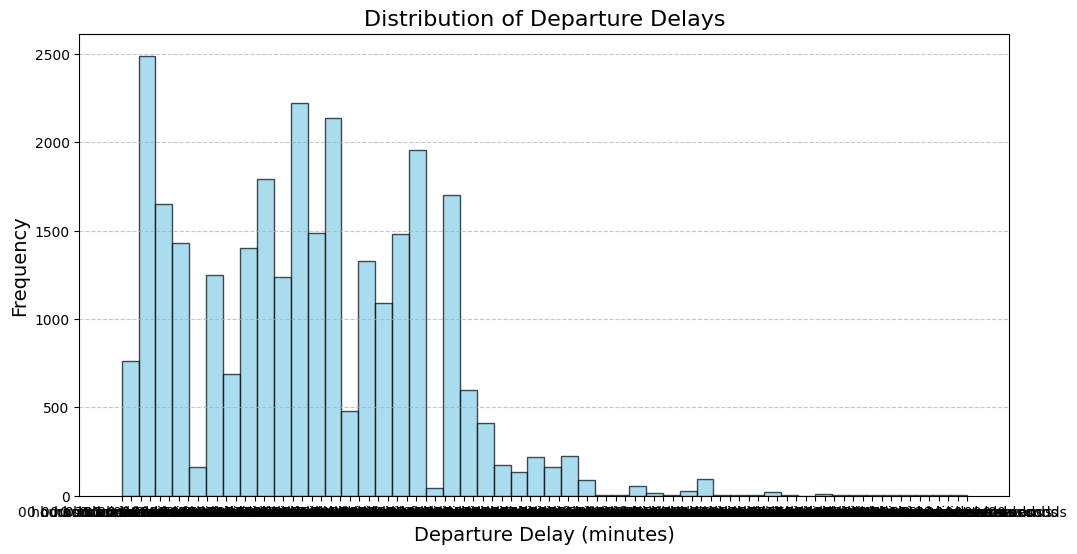

In [32]:
plt.figure(figsize=(12, 6))  
plt.hist(df['departure_delay'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Departure Delays', fontsize=16)
plt.xlabel('Departure Delay (minutes)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

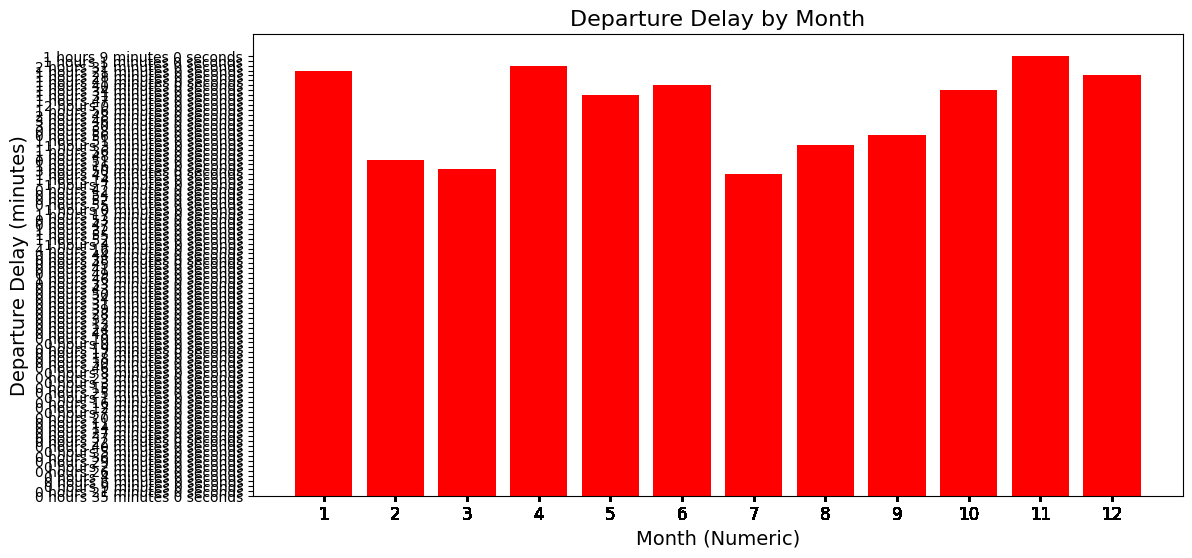

In [37]:

plt.figure(figsize=(12, 6))
plt.bar(df['month'], df['departure_delay'],  color='red')
plt.xticks(df['month'], labels=df['month'], fontsize=12)  # Use numeric months
plt.title('Departure Delay by Month', fontsize=16)
plt.xlabel('Month (Numeric)', fontsize=14)
plt.ylabel('Departure Delay (minutes)', fontsize=14)
plt.show()

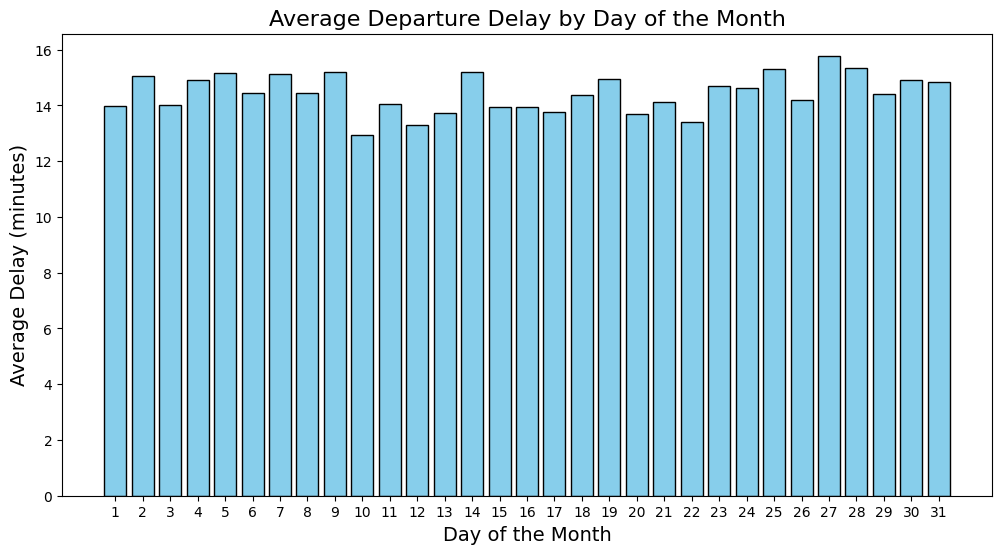

In [43]:
import re
def time_to_minutes(time_str):
    match = re.match(r'(\d+)\s*hours\s*(\d+)\s*minutes\s*(\d+)\s*seconds', time_str)
    if match:
        hours, minutes, seconds = map(int, match.groups())
        return hours * 60 + minutes + seconds / 60  # Convert total to minutes
    return 0  

# Apply the conversion
df['total_minutes'] = df['departure_delay'].apply(time_to_minutes)

# Group by day and calculate the average delay
daily_delays = df.groupby('day')['total_minutes'].mean().reset_index()

# Plot bar chart
plt.figure(figsize=(12, 6))
plt.bar(daily_delays['day'], daily_delays['total_minutes'], color='skyblue', edgecolor='black')
plt.title('Average Departure Delay by Day of the Month', fontsize=16)
plt.xlabel('Day of the Month', fontsize=14)
plt.ylabel('Average Delay (minutes)', fontsize=14)
plt.xticks(range(1, 32))  # Ensure all days (1-31) are on the x-axis
plt.show()

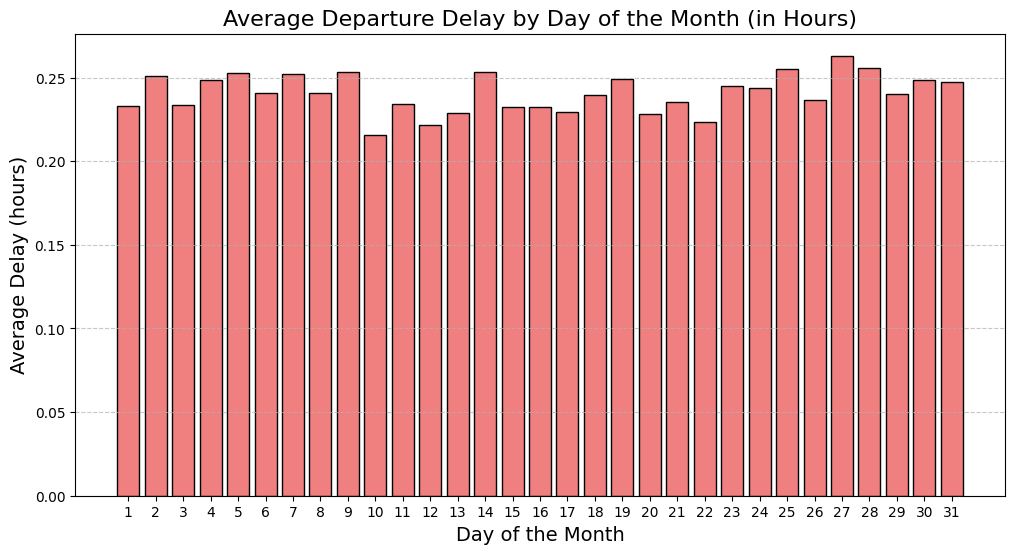

In [171]:
def time_to_hours(time_str):
    match = re.match(r'(\d+)\s*hours\s*(\d+)\s*minutes\s*(\d+)\s*seconds', time_str)
    if match:
        hours, minutes, seconds = map(int, match.groups())
        return hours + (minutes / 60) + (seconds / 3600)  # Convert everything to hours
    return 0  
    
df['total_hours'] = df['departure_delay'].apply(time_to_hours)


daily_delays = df.groupby('day')['total_hours'].mean().reset_index()


plt.figure(figsize=(12, 6))
plt.bar(daily_delays['day'], daily_delays['total_hours'], color='lightcoral', edgecolor='black')
plt.title('Average Departure Delay by Day of the Month (in Hours)', fontsize=16)
plt.xlabel('Day of the Month', fontsize=14)
plt.ylabel('Average Delay (hours)', fontsize=14)
plt.xticks(range(1, 32))  # Ensure all days (1-31) are on the x-axis
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [170]:
df.head()

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day,departure_delay
0,active,lhe,opla,2023-07-20 20:50:00,2023-07-20 20:00:00,2023-07-20 20:15:00,2023-07-20 20:15:00,2023-07-20 20:15:00,ruh,oerk,2023-07-20 23:20:00,2023-07-20 21:54:00,saudia,sv,sva,2023,7,20,0 hours 35 minutes 0 seconds
3,active,lhe,opla,2023-07-26 23:30:00,2023-07-26 23:30:00,2023-07-26 23:51:00,2023-07-26 23:51:00,2023-07-26 23:51:00,kwi,okkk,2023-07-27 01:30:00,2023-07-27 01:24:00,pakistan international airlines,pk,pia,2023,7,26,0 hours 21 minutes 0 seconds
10,active,lhe,opla,2023-07-24 10:45:00,2023-07-24 10:45:00,2023-07-24 10:54:00,2023-07-24 10:54:00,2023-07-24 10:54:00,bgw,orbi,2023-07-24 13:10:00,2023-07-24 12:44:00,fly baghdad,if,fba,2023,7,24,0 hours 9 minutes 0 seconds
14,active,lhe,opla,2023-07-27 03:30:00,2023-07-27 03:30:00,2023-07-27 03:36:00,2023-07-27 03:36:00,2023-07-27 03:36:00,doh,othh,2023-07-27 05:30:00,2023-07-27 04:38:00,american airlines,aa,aal,2023,7,27,0 hours 6 minutes 0 seconds
16,active,lhe,opla,2023-07-22 21:10:00,2023-07-22 21:10:00,2023-07-22 21:06:00,2023-07-22 21:06:00,2023-07-22 21:06:00,doh,othh,2023-07-22 23:10:00,2023-07-22 22:09:00,american airlines,aa,aal,2023,7,22,0 hours 4 minutes 0 seconds


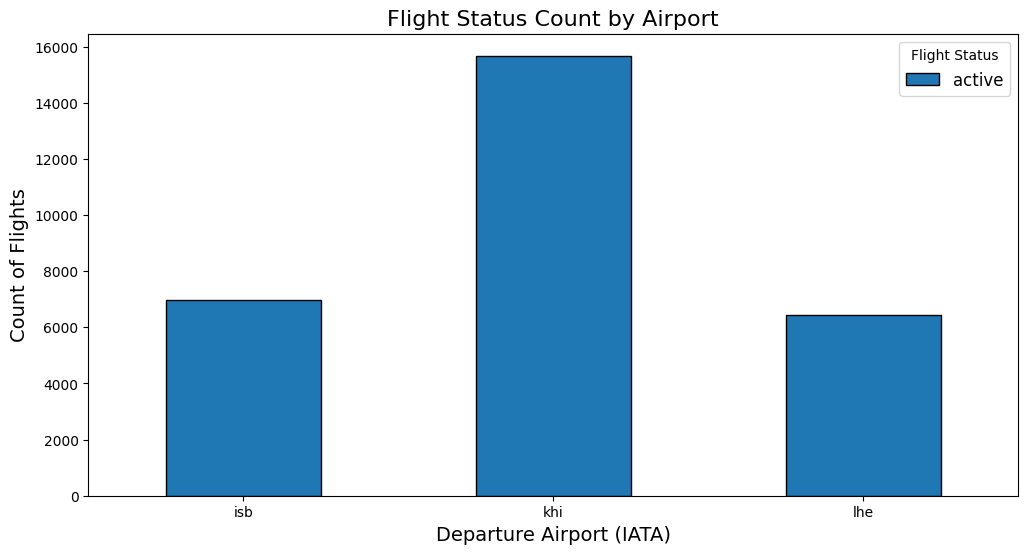

In [81]:
grouped_counts = df.groupby(['departure_iata', 'status']).size().unstack()

# Plot grouped bar chart
grouped_counts.plot(kind='bar', figsize=(12, 6), edgecolor='black')

# Add titles and labels
plt.title('Flight Status Count by Airport', fontsize=16)
plt.xlabel('Departure Airport (IATA)', fontsize=14)
plt.ylabel('Count of Flights', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Flight Status', fontsize=12)
plt.show()

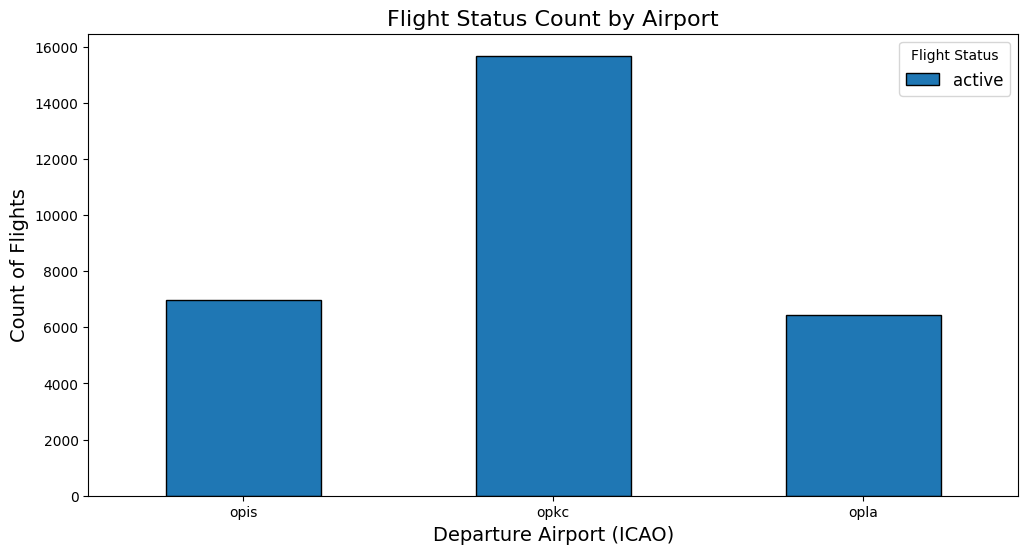

In [87]:
grouped_counts = df.groupby(['departure_icao', 'status']).size().unstack()

# Plot grouped bar chart
grouped_counts.plot(kind='bar', figsize=(12, 6), edgecolor='black')

# Add titles and labels
plt.title('Flight Status Count by Airport', fontsize=16)
plt.xlabel('Departure Airport (ICAO)', fontsize=14)
plt.ylabel('Count of Flights', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Flight Status', fontsize=12)
plt.show()

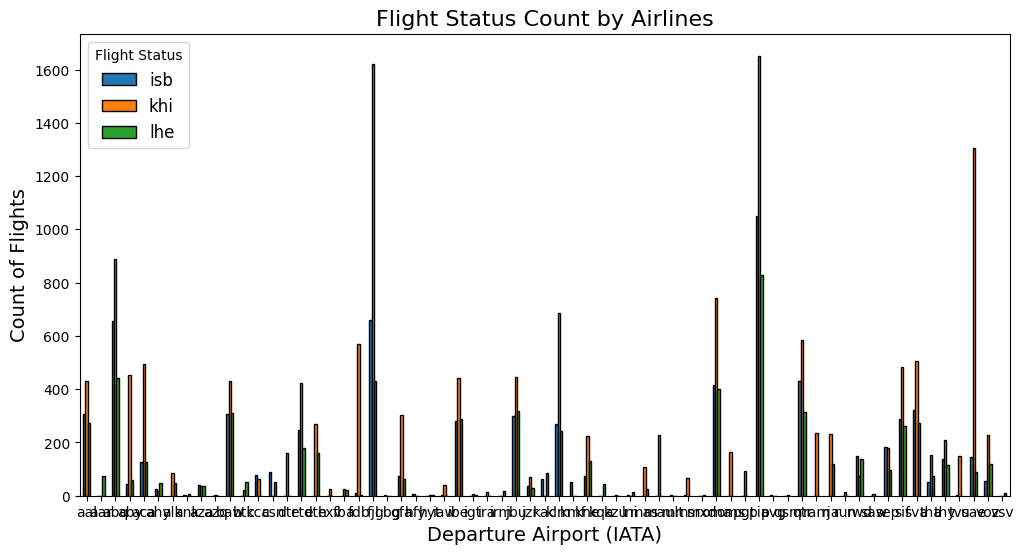

In [88]:
grouped_counts = df.groupby(['airline_icao', 'departure_iata']).size().unstack()

# Plot grouped bar chart
grouped_counts.plot(kind='bar', figsize=(12, 6), edgecolor='black')

# Add titles and labels
plt.title('Flight Status Count by Airlines', fontsize=16)
plt.xlabel('Departure Airport (IATA)', fontsize=14)
plt.ylabel('Count of Flights', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Flight Status', fontsize=12)
plt.show()

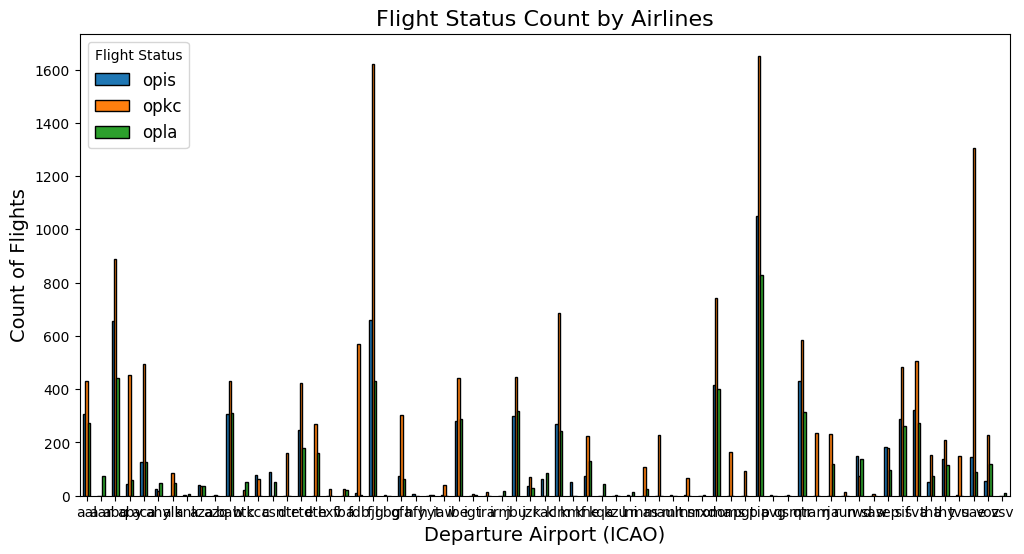

In [89]:
grouped_counts = df.groupby(['airline_icao', 'departure_icao']).size().unstack()

# Plot grouped bar chart
grouped_counts.plot(kind='bar', figsize=(12, 6), edgecolor='black')

# Add titles and labels
plt.title('Flight Status Count by Airlines', fontsize=16)
plt.xlabel('Departure Airport (ICAO)', fontsize=14)
plt.ylabel('Count of Flights', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Flight Status', fontsize=12)
plt.show()

# Correlation Analysis

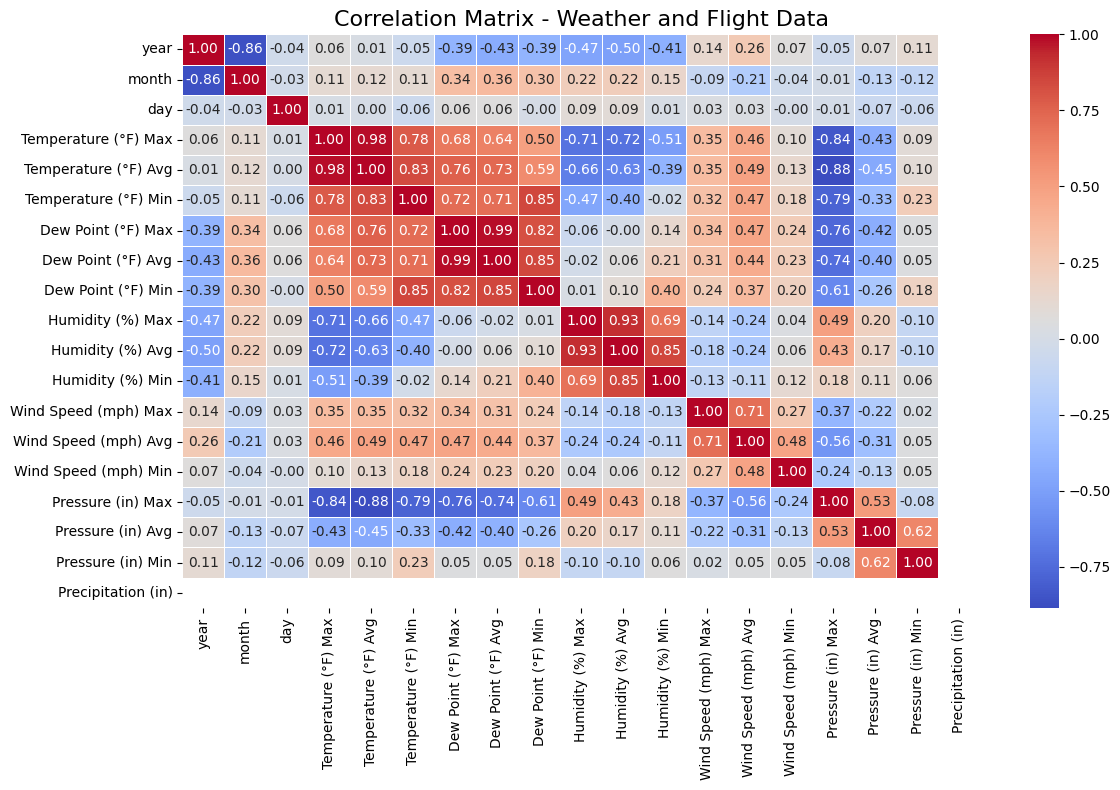

In [99]:
numeric_df = merged_df.select_dtypes(include=[np.number])

# Compute the correlation matrix
plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Weather and Flight Data', fontsize=16)
plt.tight_layout()
plt.show()

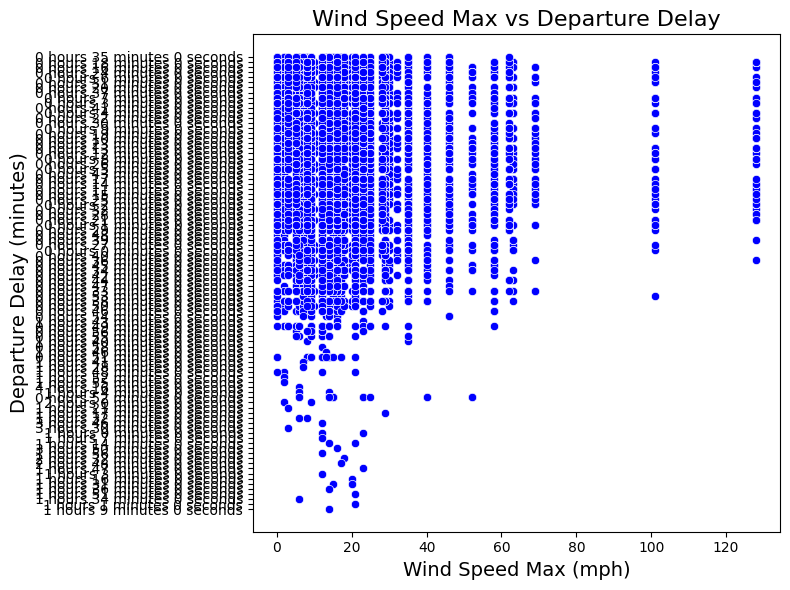

In [111]:
# 2. Scatter Plot: Wind Speed Max vs. Departure Delay

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Wind Speed (mph) Max', y='departure_delay', data=merged_df, color='blue')
plt.title('Wind Speed Max vs Departure Delay', fontsize=16)
plt.xlabel('Wind Speed Max (mph)', fontsize=14)
plt.ylabel('Departure Delay (minutes)', fontsize=14)
plt.tight_layout()
plt.show()

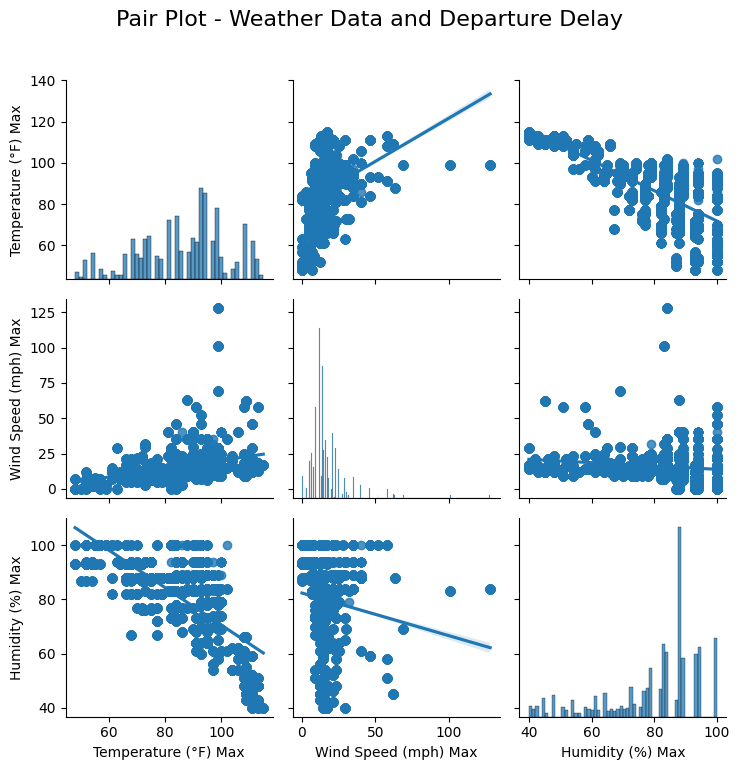

In [110]:
# 3. Pair Plot: Temperature, Humidity, Wind Speed, and Departure Delay
sns.pairplot(merged_df[['Temperature (°F) Max', 'Wind Speed (mph) Max', 'Humidity (%) Max', 'departure_delay']], kind='reg')
plt.suptitle('Pair Plot - Weather Data and Departure Delay', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Comparison

In [114]:
zero_delay_rows = df[df['departure_delay'] == '0 hours 0 minutes 0 seconds']

In [115]:
zero_delay_rows

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,arrival_scheduled,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day,departure_delay,total_hours
227,active,lhe,opla,2023-07-23 04:25:00,2023-07-23 04:00:00,2023-07-23 04:25:00,2023-07-23 04:25:00,2023-07-23 04:25:00,ruh,oerk,2023-07-23 06:15:00,2023-07-23 06:09:00,flynas,xy,kne,2023,7,23,0 hours 0 minutes 0 seconds,0.0
388,active,lhe,opla,2023-07-23 09:50:00,2023-07-23 09:50:00,2023-07-23 09:50:00,2023-07-23 09:50:00,2023-07-23 09:50:00,mct,ooms,2023-07-23 11:50:00,2023-07-23 11:17:00,oman air,wy,oma,2023,7,23,0 hours 0 minutes 0 seconds,0.0
1168,active,lhe,opla,2023-12-08 20:20:00,2023-12-08 20:20:00,2023-12-08 20:20:00,2023-12-08 20:20:00,2023-12-08 20:20:00,auh,omaa,2023-12-08 23:05:00,2023-12-08 22:31:00,etihad airways,ey,etd,2023,12,8,0 hours 0 minutes 0 seconds,0.0
1611,active,lhe,opla,2023-12-16 19:10:00,2023-12-16 19:10:00,2023-12-16 19:10:00,2023-12-16 19:10:00,2023-12-16 19:10:00,dmm,oedf,2023-12-16 21:10:00,2023-12-16 20:57:00,pakistan international airlines,pk,pia,2023,12,16,0 hours 0 minutes 0 seconds,0.0
1630,active,lhe,opla,2023-12-20 10:30:00,2023-12-20 10:30:00,2023-12-20 10:30:00,2023-12-20 10:30:00,2023-12-20 10:30:00,njf,orni,2023-12-20 13:15:00,2023-12-20 13:10:00,fly baghdad,if,fba,2023,12,20,0 hours 0 minutes 0 seconds,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50684,active,lhe,opla,2023-11-10 01:35:00,2023-11-10 01:35:00,2023-11-10 01:35:00,2023-11-10 01:35:00,2023-11-10 01:35:00,jed,oejn,2023-11-10 05:10:00,2023-11-10 04:40:00,serene air,er,sep,2023,11,10,0 hours 0 minutes 0 seconds,0.0
50900,active,lhe,opla,2023-11-05 04:20:00,2023-11-05 04:20:00,2023-11-05 04:20:00,2023-11-05 04:20:00,2023-11-05 04:20:00,auh,omaa,2023-11-05 07:05:00,2023-11-05 06:25:00,klm,kl,klm,2023,11,5,0 hours 0 minutes 0 seconds,0.0
51213,active,lhe,opla,2023-11-18 03:00:00,2023-11-18 03:00:00,2023-11-18 03:00:00,2023-11-18 03:00:00,2023-11-18 03:00:00,gyd,ubbb,2023-11-18 06:40:00,2023-11-18 06:08:00,azal azerbaijan airlines,j2,ahy,2023,11,18,0 hours 0 minutes 0 seconds,0.0
51515,active,lhe,opla,2023-11-18 20:20:00,2023-11-18 20:21:00,2023-11-18 20:20:00,2023-11-18 20:20:00,2023-11-18 20:20:00,auh,omaa,2023-11-18 23:05:00,2023-11-18 22:27:00,klm,kl,klm,2023,11,18,0 hours 0 minutes 0 seconds,0.0


# Binary Classification


In [172]:
df['delay'] = np.where(df['total_hours'] == 0, 'on-time', 'delayed')

In [173]:
df['delay'] = df['delay'].map({'on-time': 0, 'delayed': 1})

In [131]:
df['delay'].value_counts()

delay
1    28513
0      564
Name: count, dtype: int64

In [123]:
# Check for data types in the dataset
print(df.dtypes)


status                                object
departure_iata                        object
departure_icao                        object
departure_scheduled           datetime64[ns]
departure_estimated           datetime64[ns]
departure_actual              datetime64[ns]
departure_runway_estimated    datetime64[ns]
departure_runway_actual       datetime64[ns]
arrival_iata                          object
arrival_icao                          object
arrival_scheduled             datetime64[ns]
arrival_estimated             datetime64[ns]
airline_name                          object
airline_iata                          object
airline_icao                          object
year                                   int32
month                                  int32
day                                    int32
departure_delay                       object
total_hours                          float64
delay                                 object
dtype: object


In [132]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_curve, f1_score, classification_report, confusion_matrix

X = df[['year', 'month', 'day',
        'total_hours',]]
y = df['delay']

#. Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [133]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [137]:
# . Train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

#Predict on the test set
y_pred = model.predict(X_test)

#  Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

#  Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])

#  F1-Score
f1 = f1_score(y_test, y_pred)
print(f'F1-Score: {f1:.4f}')

#  Classification Report (includes Precision, Recall, F1-Score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))





Accuracy: 0.9998
F1-Score: 0.9999

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       114
           1       1.00      1.00      1.00      5702

    accuracy                           1.00      5816
   macro avg       1.00      1.00      1.00      5816
weighted avg       1.00      1.00      1.00      5816



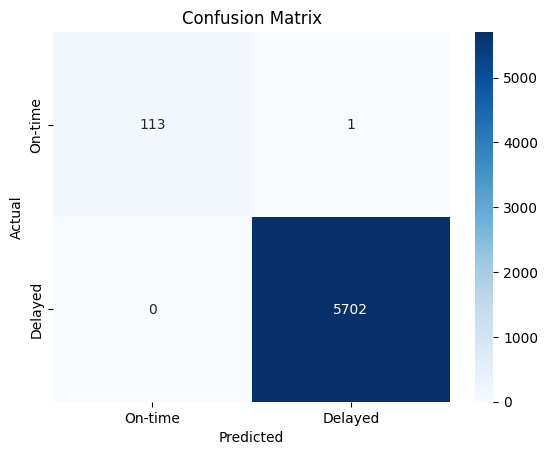

In [135]:
#  Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['On-time', 'Delayed'], yticklabels=['On-time', 'Delayed'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

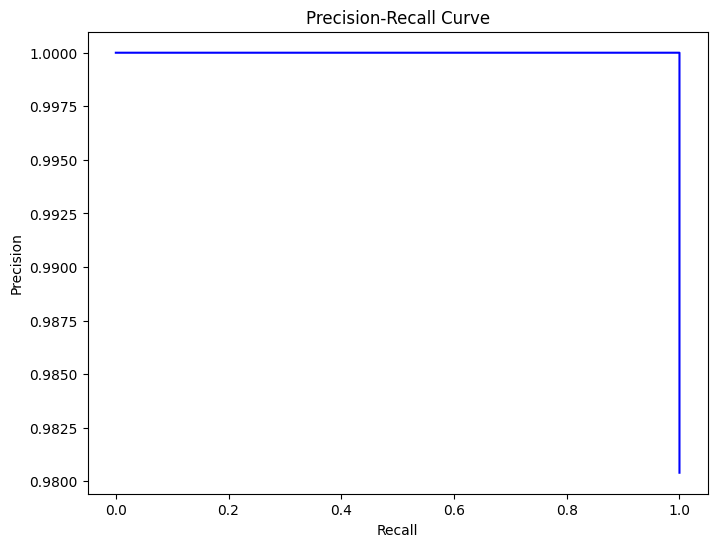

In [136]:
#  Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


# Multi Class Classification

In [138]:
df.head()

,status,departure_iata,departure_icao,departure_scheduled,departure_estimated,departure_actual,departure_runway_estimated,departure_runway_actual,arrival_iata,arrival_icao,...,arrival_estimated,airline_name,airline_iata,airline_icao,year,month,day,departure_delay,total_hours,delay
0,active,lhe,opla,2023-07-20 20:50:00,2023-07-20 20:00:00,2023-07-20 20:15:00,2023-07-20 20:15:00,2023-07-20 20:15:00,ruh,oerk,...,2023-07-20 21:54:00,saudia,sv,sva,2023,7,20,0 hours 35 minutes 0 seconds,0.583333,1
3,active,lhe,opla,2023-07-26 23:30:00,2023-07-26 23:30:00,2023-07-26 23:51:00,2023-07-26 23:51:00,2023-07-26 23:51:00,kwi,okkk,...,2023-07-27 01:24:00,pakistan international airlines,pk,pia,2023,7,26,0 hours 21 minutes 0 seconds,0.350000,1
10,active,lhe,opla,2023-07-24 10:45:00,2023-07-24 10:45:00,2023-07-24 10:54:00,2023-07-24 10:54:00,2023-07-24 10:54:00,bgw,orbi,...,2023-07-24 12:44:00,fly baghdad,if,fba,2023,7,24,0 hours 9 minutes 0 seconds,0.150000,1
14,active,lhe,opla,2023-07-27 03:30:00,2023-07-27 03:30:00,2023-07-27 03:36:00,2023-07-27 03:36:00,2023-07-27 03:36:00,doh,othh,...,2023-07-27 04:38:00,american airlines,aa,aal,2023,7,27,0 hours 6 minutes 0 seconds,0.100000,1
16,active,lhe,opla,2023-07-22 21:10:00,2023-07-22 21:10:00,2023-07-22 21:06:00,2023-07-22 21:06:00,2023-07-22 21:06:00,doh,othh,...,2023-07-22 22:09:00,american airlines,aa,aal,2023,7,22,0 hours 4 minutes 0 seconds,0.066667,1


In [174]:
def categorize_delay(hour):
    if hour == 0:
        return 'No Delay'
    elif 0 < hour < 0.75:
        return 'Short Delay'
    elif 0.75 <= hour <= 2.9167:
        return 'Moderate Delay'
    else:
        return 'Long Delay'

df['multi_delay'] = df['total_hours'].apply(categorize_delay)

In [144]:
df['multi_delay'].value_counts()

multi_delay
Short Delay       28075
No Delay            564
Moderate Delay      434
Long Delay            4
Name: count, dtype: int64

In [145]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


df['multi_delay'] = df['multi_delay'].map({'No Delay': 0, 'Short Delay': 1, 'Moderate Delay': 2, 'Long Delay': 3})

#  Splitting the data into features (X) and target (y)
X = df[['year', 'month', 'day',
        'total_hours',]]
y = df['multi_delay']

#  Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train the Random Forest model for multi-class classification
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust n_estimators and other hyperparameters

# Train the model
rf_model.fit(X_train, y_train)

# Predict the test set
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       114
           1       1.00      1.00      1.00      5614
           2       0.99      1.00      0.99        87
           3       0.00      0.00      0.00         1

    accuracy                           1.00      5816
   macro avg       0.75      0.75      0.75      5816
weighted avg       1.00      1.00      1.00      5816


Confusion Matrix:
[[ 114    0    0    0]
 [   0 5614    0    0]
 [   0    0   87    0]
 [   0    0    1    0]]


C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

# Regresiion Analysis

In [177]:

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Features (X) and Target (y)
X = df[['year', 'month', 'day']] # Drop the target column from the features
y = df['total_hours']  # This is the delay duration we want to predict

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train the Regression Model (Random Forest Regressor)
rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rfr_model.fit(X_train, y_train)

#  Evaluate using Cross-Validation (e.g., 5-fold cross-validation)
cross_val_scores = cross_val_score(rfr_model, X, y, cv=5, scoring='neg_mean_absolute_error')

#  Predictions and Performance Evaluation on Test Set
y_pred = rfr_model.predict(X_test)

#  Calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print Cross-Validation Scores and Evaluation Metrics
print(f"Cross-validation MAE Scores: {cross_val_scores}")
print(f"Mean Cross-validation MAE: {-cross_val_scores.mean()}")

print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


Cross-validation MAE Scores: [-0.14789245 -0.14143087 -0.14512361 -0.13829016 -0.13955068]
Mean Cross-validation MAE: 0.14245755348043038

Mean Absolute Error (MAE): 0.1399
Root Mean Squared Error (RMSE): 0.1905


# Model Optimization and Evaluation

Accuracy: 0.9998


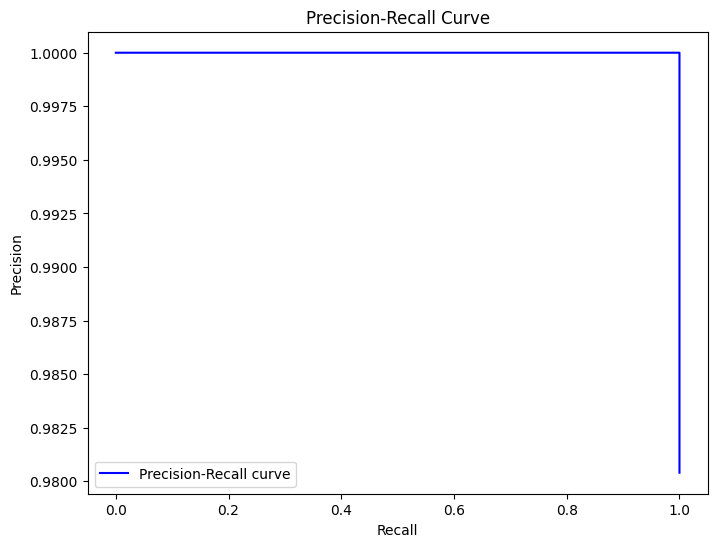

F1-Score: 0.9999

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       114
           1       1.00      1.00      1.00      5702

    accuracy                           1.00      5816
   macro avg       1.00      1.00      1.00      5816
weighted avg       1.00      1.00      1.00      5816



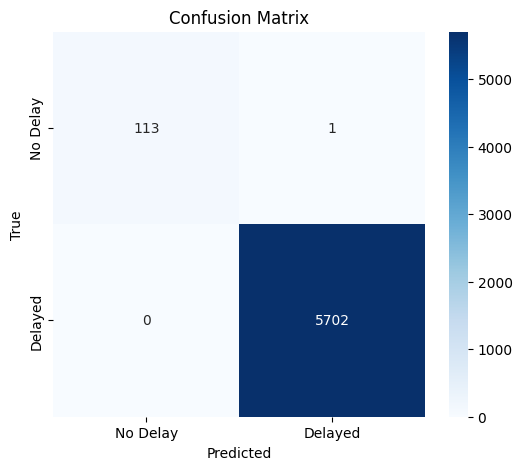

Fitting 5 folds for each of 12 candidates, totalling 60 fits


C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "

Best Hyperparameters from GridSearchCV: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Model Accuracy: 1.0000
Best Model F1-Score: 1.0000


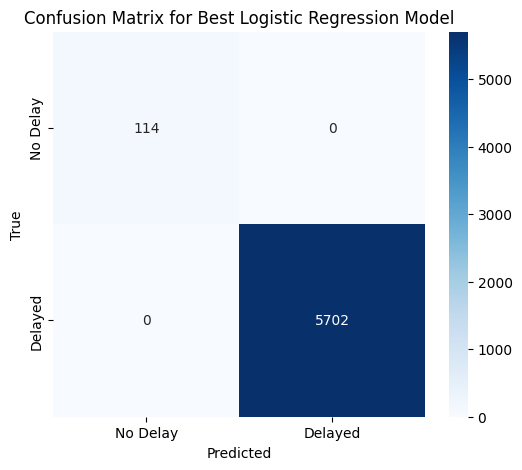

Cross-Validation Accuracy: 1.0000


In [149]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = df[['year', 'month', 'day',
        'total_hours',]]
y = df['delay']

#  Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  Logistic Regression Model without Hyperparameter Tuning
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#  Predict on the test set
y_pred = model.predict(X_test)

#  Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

#  Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# 5. F1-Score
f1 = f1_score(y_test, y_pred)
print(f'F1-Score: {f1:.4f}')

#  Classification Report (includes Precision, Recall, F1-Score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#  Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['No Delay', 'Delayed'], yticklabels=['No Delay', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

#  Hyperparameter Tuning for Logistic Regression using GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],  # Regularization strength
    'penalty': ['l2', 'elasticnet'],  # Regularization type
    'solver': ['lbfgs', 'liblinear']  # Solvers to try
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)

#  Evaluate the Best Model from Grid Search
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

# Re-evaluate the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f'Best Model Accuracy: {accuracy_best:.4f}')
print(f'Best Model F1-Score: {f1_best:.4f}')

#  Confusion Matrix for the best model
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_best, annot=True, fmt="d", cmap="Blues", xticklabels=['No Delay', 'Delayed'], yticklabels=['No Delay', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Best Logistic Regression Model')
plt.show()

# 11. Cross-validation for the best model
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy: {cv_scores.mean():.4f}')



Accuracy: 0.9998

Classification Report:


C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

                precision    recall  f1-score   support

    Long Delay       0.00      0.00      0.00         1
Moderate Delay       0.99      1.00      0.99        87
      No Delay       1.00      1.00      1.00       114
   Short Delay       1.00      1.00      1.00      5614

      accuracy                           1.00      5816
     macro avg       0.75      0.75      0.75      5816
  weighted avg       1.00      1.00      1.00      5816



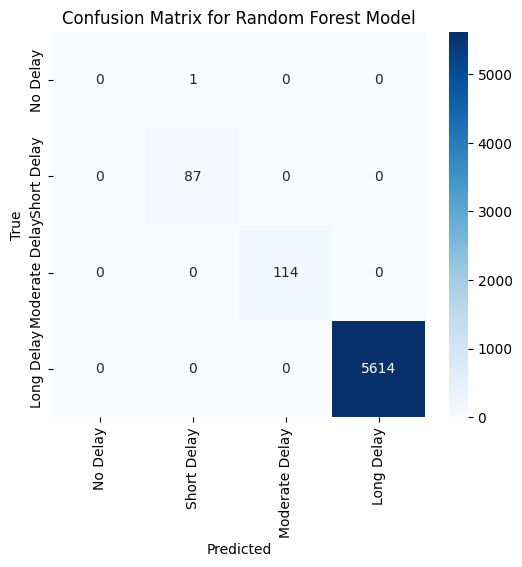

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best Hyperparameters from GridSearchCV: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Model Accuracy: 0.9998

Best Model Classification Report:


C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

                precision    recall  f1-score   support

    Long Delay       0.00      0.00      0.00         1
Moderate Delay       0.99      1.00      0.99        87
      No Delay       1.00      1.00      1.00       114
   Short Delay       1.00      1.00      1.00      5614

      accuracy                           1.00      5816
     macro avg       0.75      0.75      0.75      5816
  weighted avg       1.00      1.00      1.00      5816



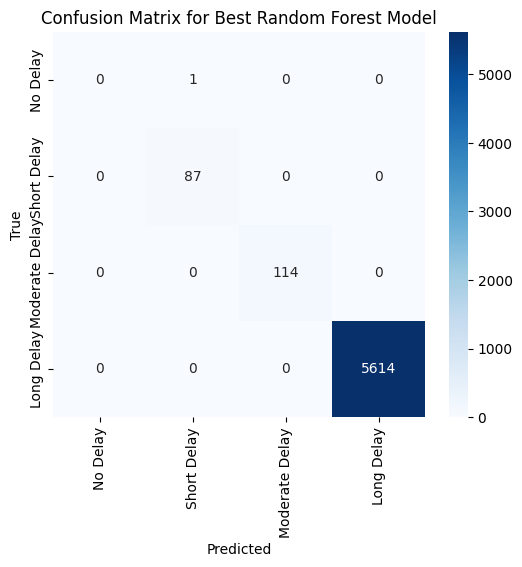

C:\Users\Arslan Javed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Accuracy: 1.0000


In [175]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



#  Splitting the data into features (X) and target (y)
X = df[['year', 'month', 'day', 'total_hours']]
y = df['multi_delay']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest model for multi-class classification
rf_model = RandomForestClassifier(random_state=42)

# Train the model without tuning to get a baseline
rf_model.fit(X_train, y_train)

#  Predict the test set
y_pred = rf_model.predict(X_test)

#  Evaluate the model without tuning
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['No Delay', 'Short Delay', 'Moderate Delay', 'Long Delay'],
            yticklabels=['No Delay', 'Short Delay', 'Moderate Delay', 'Long Delay'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()

#  Hyperparameter Tuning for Random Forest using GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4]     # Minimum number of samples required at a leaf node
}

# Grid Search with Cross-Validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Parameters from Grid Search
print("Best Hyperparameters from GridSearchCV:", grid_search.best_params_)

#  Evaluate the Best Model from Grid Search
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)

# Re-evaluate the best model
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Best Model Accuracy: {accuracy_best:.4f}")

# Classification Report for Best Model
print("\nBest Model Classification Report:")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix for the Best Model
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_best, annot=True, fmt="d", cmap="Blues", xticklabels=['No Delay', 'Short Delay', 'Moderate Delay', 'Long Delay'],
            yticklabels=['No Delay', 'Short Delay', 'Moderate Delay', 'Long Delay'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Best Random Forest Model')
plt.show()

#  Cross-validation for the Best Model
cv_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-Validation Accuracy: {cv_scores.mean():.4f}')


Cross-validation MAE Scores: [0.14789245 0.14143087 0.14512361 0.13829016 0.13955068]
Mean Cross-validation MAE: 0.1425

Mean Absolute Error (MAE) on Test Set: 0.1399
Root Mean Squared Error (RMSE) on Test Set: 0.1905

Best Hyperparameters from GridSearchCV: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}

Best Model - Mean Absolute Error (MAE): 0.1397
Best Model - Root Mean Squared Error (RMSE): 0.1900


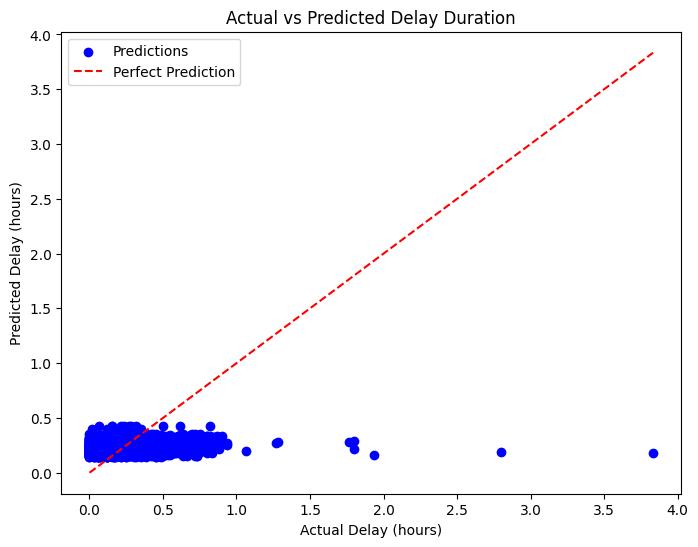

Cross-Validation MAE for Best Model: 0.1376


In [153]:

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Features (X) and Target (y)
X = df[['year', 'month', 'day']]  # Features excluding the target column
y = df['total_hours']  # The delay duration to predict

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train the Regression Model (Random Forest Regressor)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

#  Cross-validation to evaluate the model (e.g., 5-fold cross-validation)
cross_val_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error')

#  Predictions and Performance Evaluation on Test Set
y_pred = rf_model.predict(X_test)

#  Calculate MAE and RMSE on Test Set
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print Cross-Validation Scores and Evaluation Metrics
print(f"Cross-validation MAE Scores: {-cross_val_scores}")
print(f"Mean Cross-validation MAE: {-cross_val_scores.mean():.4f}")
print(f"\nMean Absolute Error (MAE) on Test Set: {mae:.4f}")
print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.4f}")

# Hyperparameter Tuning using GridSearchCV for Random Forest Regressor
param_grid = {
    'n_estimators': [50, 100, 150],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required at a leaf node
}

# Grid Search for Best Parameters
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best Hyperparameters from GridSearchCV
print("\nBest Hyperparameters from GridSearchCV:", grid_search.best_params_)

#  Evaluate the Best Model from Grid Search
best_rf_model = grid_search.best_estimator_
y_pred_best = best_rf_model.predict(X_test)

# Re-evaluate the best model
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"\nBest Model - Mean Absolute Error (MAE): {mae_best:.4f}")
print(f"Best Model - Root Mean Squared Error (RMSE): {rmse_best:.4f}")

#  Plotting Actual vs Predicted for the Best Model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, color='blue', label='Predictions')
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Delay (hours)')
plt.ylabel('Predicted Delay (hours)')
plt.title('Actual vs Predicted Delay Duration')
plt.legend()
plt.show()

#  Cross-validation for the Best Model
cv_scores_best = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f'Cross-Validation MAE for Best Model: {-cv_scores_best.mean():.4f}')


# Saving Models

In [178]:
import joblib
joblib.dump(model, 'binary.pkl')
joblib.dump(rf_model, 'multiclass.pkl')
joblib.dump(rfr_model, 'regression.pkl')

['regression.pkl']